In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install faiss-cpu sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 76.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.3 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incom

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch
import time
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

In [4]:
print("Loading embedding model...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedding model loaded.")

# Quick test
test_vec = embedder.encode(["hello world"])[0]
print(f"Embedding dimension: {len(test_vec)}")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.
Embedding dimension: 384


In [5]:
print("Loading LLM... (this takes 5-10 mins on first run)")

model_name = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLM loaded successfully.")
print(f"Device: {next(model.parameters()).device}")

Loading LLM... (this takes 5-10 mins on first run)


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

LLM loaded successfully.
Device: cuda:0


In [6]:
class TokenReuseBuffer:
    def __init__(self, embedding_dim=384, similarity_threshold=0.65):
        self.threshold = similarity_threshold
        self.dim = embedding_dim
        
        # FAISS flat index — exact L2 search
        # This is the upgrade from the original PDF's linear scan
        self.index = faiss.IndexFlatIP(embedding_dim)  # Inner Product = cosine on normalized vecs
        
        self.texts = []       # stored queries
        self.responses = []   # stored responses
        self.stats = []       # per-query stats log
        
        print(f"TRB initialized | dim={embedding_dim} | threshold={similarity_threshold}")
    
    def _embed(self, text):
        vec = embedder.encode([text])[0]
        vec = vec / np.linalg.norm(vec)  # normalize for cosine similarity
        return vec.astype(np.float32)
    
    def _count_tokens(self, text):
        return len(tokenizer.encode(text))
    
    def search(self, query):
        if self.index.ntotal == 0:
            return -1, 0.0
        qvec = self._embed(query).reshape(1, -1)
        scores, indices = self.index.search(qvec, 1)
        return int(indices[0][0]), float(scores[0][0])
    
    def add(self, query, response):
        vec = self._embed(query).reshape(1, -1)
        self.index.add(vec)
        self.texts.append(query)
        self.responses.append(response)
    
    def _generate(self, prompt):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,       # greedy decoding for reproducibility
                temperature=1.0
            )
        full = tokenizer.decode(out[0], skip_special_tokens=True)
        # strip the prompt from the output
        return full[len(prompt):].strip()
    
    def query(self, q):
        idx, score = self.search(q)
        
        t_start = time.time()
        
        if idx != -1 and score >= self.threshold:
            # ===== CACHE HIT =====
            prev_prompt = self.texts[idx] + "\n" + self.responses[idx] + "\n" + q
            curr_prompt  = self.texts[idx] + "\n[REUSED CONTEXT]\n" + q
            
            prev_tokens = self._count_tokens(prev_prompt)
            curr_tokens = self._count_tokens(curr_prompt)
            
            response = self._generate(curr_prompt)
            cache_hit = True
            
            print(f"\n{'='*50}")
            print(f"CACHE HIT | similarity={score:.3f}")
            print(f"Matched query : '{self.texts[idx]}'")
            print(f"Tokens before : {prev_tokens} | after : {curr_tokens} | saved : {prev_tokens - curr_tokens}")
        else:
            # ===== CACHE MISS =====
            prev_tokens = self._count_tokens(q)
            curr_tokens = prev_tokens
            
            response = self._generate(q)
            self.add(q, response)
            cache_hit = False
            
            print(f"\n{'='*50}")
            print(f"CACHE MISS | query stored in buffer")
            print(f"Tokens: {curr_tokens}")
        
        latency = round(time.time() - t_start, 2)
        
        self.stats.append({
            "query": q,
            "cache_hit": cache_hit,
            "similarity_score": round(score, 3),
            "prev_tokens": prev_tokens,
            "curr_tokens": curr_tokens,
            "saved_tokens": prev_tokens - curr_tokens,
            "latency_sec": latency
        })
        
        return response

trb = TokenReuseBuffer(similarity_threshold=0.65)
print("TRB instance ready.")

TRB initialized | dim=384 | threshold=0.65
TRB instance ready.


In [7]:
print("\n" + "="*60)
print("DOMAIN 1: Machine Learning Concepts")
print("="*60)

ml_queries = [
    "Explain what a neural network is",
    "What is backpropagation in neural networks",
    "How does gradient descent work in neural networks",
    "What is overfitting in neural networks",
    "How to prevent overfitting in deep learning"
]

ml_responses = []
for q in ml_queries:
    print(f"\nQuery: {q}")
    r = trb.query(q)
    ml_responses.append(r)
    print(f"Response preview: {r[:120]}...")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



DOMAIN 1: Machine Learning Concepts

Query: Explain what a neural network is

CACHE MISS | query stored in buffer
Tokens: 7
Response preview: and provide an example of how it can be used in a real-world application.
A neural network is a type of machine learning...

Query: What is backpropagation in neural networks

CACHE HIT | similarity=0.656
Matched query : 'Explain what a neural network is'
Tokens before : 167 | after : 21 | saved : 146
Response preview: ?

Backpropagation is an algorithm used to train artificial neural networks. It works by calculating the gradient of the...

Query: How does gradient descent work in neural networks

CACHE MISS | query stored in buffer
Tokens: 8
Response preview: ? Gradient descent is an optimization algorithm used to minimize the cost function of a neural network. The goal of trai...

Query: What is overfitting in neural networks

CACHE MISS | query stored in buffer
Tokens: 8
Response preview: , and how can it be prevented? Overfitting in neural 

In [8]:
print("\n" + "="*60)
print("DOMAIN 2: Transformer Architecture")
print("="*60)

transformer_queries = [
    "What is the transformer architecture",
    "Explain self-attention in transformers",
    "What is multi-head attention",
    "How does positional encoding work in transformers",
    "What is the encoder decoder structure in transformers"
]

for q in transformer_queries:
    print(f"\nQuery: {q}")
    r = trb.query(q)
    print(f"Response preview: {r[:120]}...")


DOMAIN 2: Transformer Architecture

Query: What is the transformer architecture

CACHE MISS | query stored in buffer
Tokens: 5
Response preview: and how does it work in natural language processing tasks? The transformer architecture is a deep learning model that wa...

Query: Explain self-attention in transformers

CACHE MISS | query stored in buffer
Tokens: 7
Response preview: and how it differs from traditional attention mechanisms. Self-attention is a mechanism used in transformer models to pr...

Query: What is multi-head attention

CACHE MISS | query stored in buffer
Tokens: 5
Response preview: in the context of transformers, and how does it work? Multi-head attention is a mechanism used in the transformer archit...

Query: How does positional encoding work in transformers

CACHE MISS | query stored in buffer
Tokens: 7
Response preview: ? Positional encoding is a crucial component of the Transformer architecture, which is used to provide information about...

Query: What is the e

In [9]:
print("\n" + "="*60)
print("FINAL STATS SUMMARY")
print("="*60)

df = pd.DataFrame(trb.stats)
print(df.to_string(index=False))

print(f"\nTotal queries     : {len(df)}")
print(f"Cache hits        : {df['cache_hit'].sum()} ({df['cache_hit'].mean()*100:.1f}%)")
print(f"Cache misses      : {(~df['cache_hit']).sum()}")
print(f"Total tokens before TRB : {df['prev_tokens'].sum()}")
print(f"Total tokens after TRB  : {df['curr_tokens'].sum()}")
print(f"Total tokens saved      : {df['saved_tokens'].sum()}")
print(f"Token reduction %       : {df['saved_tokens'].sum()/df['prev_tokens'].sum()*100:.1f}%")
print(f"Avg latency (hits)      : {df[df['cache_hit']]['latency_sec'].mean():.2f}s")
print(f"Avg latency (misses)    : {df[~df['cache_hit']]['latency_sec'].mean():.2f}s")


FINAL STATS SUMMARY
                                                query  cache_hit  similarity_score  prev_tokens  curr_tokens  saved_tokens  latency_sec
                     Explain what a neural network is      False             0.000            7            7             0        10.77
           What is backpropagation in neural networks       True             0.656          167           21           146         9.83
    How does gradient descent work in neural networks      False             0.597            8            8             0         9.73
               What is overfitting in neural networks      False             0.510            8            8             0         9.72
          How to prevent overfitting in deep learning       True             0.741          169           23           146         9.78
                 What is the transformer architecture      False             0.263            5            5             0         9.97
               Explain self

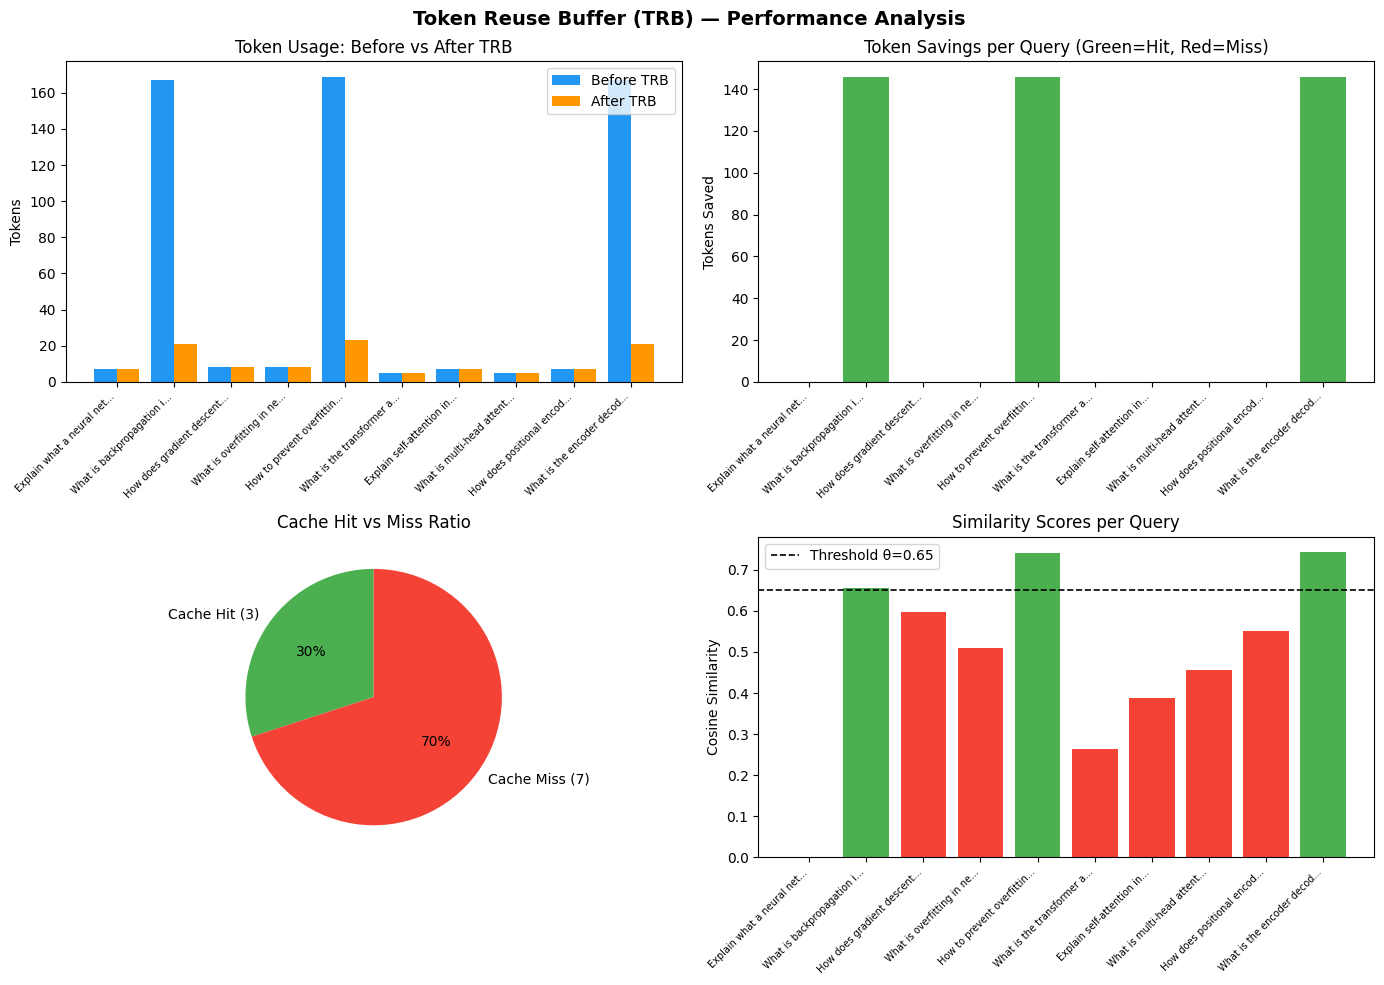

Plot saved.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Token Reuse Buffer (TRB) — Performance Analysis", fontsize=14, fontweight='bold')

queries_short = [q[:25] + "..." for q in df["query"]]

# Plot 1: Token usage before vs after
ax1 = axes[0, 0]
x = np.arange(len(df))
ax1.bar(x - 0.2, df["prev_tokens"], 0.4, label="Before TRB", color="#2196F3")
ax1.bar(x + 0.2, df["curr_tokens"], 0.4, label="After TRB",  color="#FF9800")
ax1.set_xticks(x)
ax1.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=7)
ax1.set_title("Token Usage: Before vs After TRB")
ax1.set_ylabel("Tokens")
ax1.legend()

# Plot 2: Token savings per query
ax2 = axes[0, 1]
colors = ["#4CAF50" if h else "#f44336" for h in df["cache_hit"]]
ax2.bar(queries_short, df["saved_tokens"], color=colors)
ax2.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=7)
ax2.set_title("Token Savings per Query (Green=Hit, Red=Miss)")
ax2.set_ylabel("Tokens Saved")

# Plot 3: Cache hit/miss pie
ax3 = axes[1, 0]
hit_count  = df["cache_hit"].sum()
miss_count = (~df["cache_hit"]).sum()
ax3.pie([hit_count, miss_count],
        labels=[f"Cache Hit ({hit_count})", f"Cache Miss ({miss_count})"],
        colors=["#4CAF50", "#f44336"],
        autopct="%1.0f%%", startangle=90)
ax3.set_title("Cache Hit vs Miss Ratio")

# Plot 4: Similarity scores
ax4 = axes[1, 1]
bar_colors = ["#4CAF50" if s >= 0.65 else "#f44336" for s in df["similarity_score"]]
ax4.bar(queries_short, df["similarity_score"], color=bar_colors)
ax4.axhline(y=0.65, color='black', linestyle='--', linewidth=1.2, label="Threshold θ=0.65")
ax4.set_xticklabels(queries_short, rotation=45, ha='right', fontsize=7)
ax4.set_title("Similarity Scores per Query")
ax4.set_ylabel("Cosine Similarity")
ax4.legend()

plt.tight_layout()
plt.savefig("trb_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

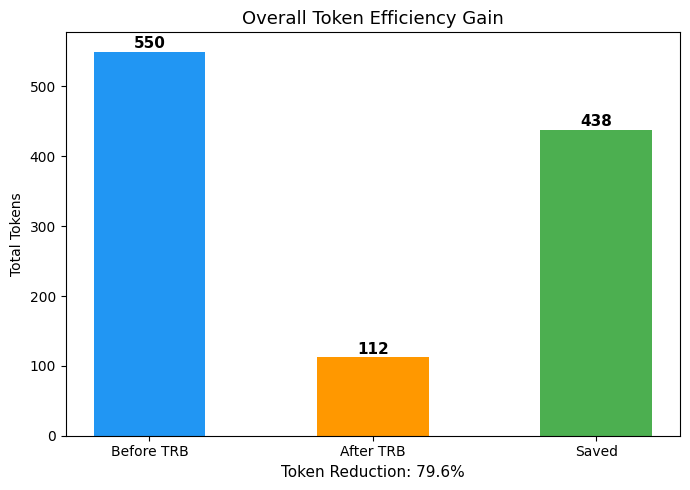

In [11]:
fig2, ax = plt.subplots(figsize=(7, 5))

total_before = df["prev_tokens"].sum()
total_after  = df["curr_tokens"].sum()
total_saved  = df["saved_tokens"].sum()

bars = ax.bar(
    ["Before TRB", "After TRB", "Saved"],
    [total_before, total_after, total_saved],
    color=["#2196F3", "#FF9800", "#4CAF50"],
    width=0.5
)

for bar, val in zip(bars, [total_before, total_after, total_saved]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_title("Overall Token Efficiency Gain", fontsize=13)
ax.set_ylabel("Total Tokens")
reduction_pct = total_saved / total_before * 100
ax.set_xlabel(f"Token Reduction: {reduction_pct:.1f}%", fontsize=11)

plt.tight_layout()
plt.savefig("trb_overall.png", dpi=150, bbox_inches='tight')
plt.show()

Running threshold sensitivity analysis...
(Uses stored embeddings only — no new LLM calls)

 threshold  hits  misses  hit_rate
      0.50     6       4       0.6
      0.55     5       5       0.5
      0.60     3       7       0.3
      0.65     3       7       0.3
      0.70     2       8       0.2
      0.75     0      10       0.0
      0.80     0      10       0.0


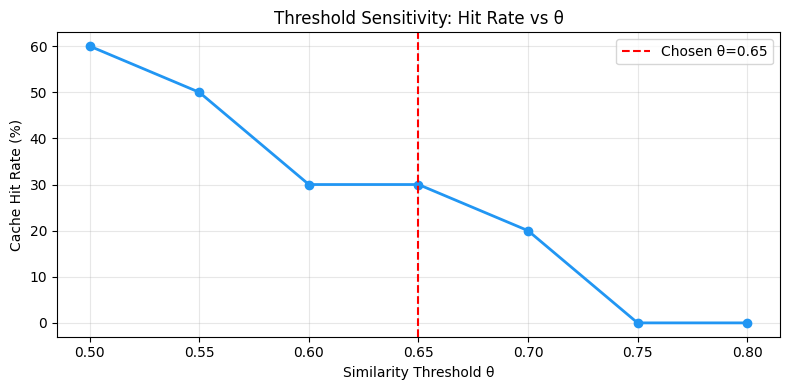

In [12]:
print("Running threshold sensitivity analysis...")
print("(Uses stored embeddings only — no new LLM calls)\n")

thresholds = [0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
sensitivity_results = []

# Re-run similarity scores we already have
sim_scores = df["similarity_score"].values

for t in thresholds:
    hits = sum(1 for s in sim_scores if s >= t)
    misses = len(sim_scores) - hits
    sensitivity_results.append({
        "threshold": t,
        "hits": hits,
        "misses": misses,
        "hit_rate": hits / len(sim_scores)
    })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(sens_df["threshold"], sens_df["hit_rate"] * 100, marker='o', color="#2196F3", linewidth=2)
plt.axvline(x=0.65, color='red', linestyle='--', label="Chosen θ=0.65")
plt.xlabel("Similarity Threshold θ")
plt.ylabel("Cache Hit Rate (%)")
plt.title("Threshold Sensitivity: Hit Rate vs θ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("trb_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()